In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from google.colab import drive

# Set visual style for publication-ready charts in your thesis
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Mount your Google Drive to this Colab session
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Point directly to the file based on your folder structure
file_path = '/content/drive/MyDrive/Capstone/Survey_AI.csv'

# 3. Load the dataset into a DataFrame
print(f"Loading data from: {file_path}")
df = pd.read_csv(file_path)

# Quick sanity check to ensure everything loaded correctly
print("\nDataset Shape:", df.shape)
display(df.head())
df.info()

Connecting to Google Drive...
Mounted at /content/drive
Loading data from: /content/drive/MyDrive/Capstone/Survey_AI.csv

Dataset Shape: (91, 35)


,ID,Q1.AI_knowledge,Q2.AI_sources,Q2#1.Internet,Q2#2.Books/Papers,Q2#3.Social_media,Q2#4.Discussions,Q2#5.NotInformed,Q3#1.AI_dehumanization,Q3#2.Job_replacement,...,Q7.Utility_grade,Q8.Advantage_teaching,Q9.Advantage_learning,Q10.Advantage_evaluation,Q11.Disadvantage_educational_process,Q12.Gender,Q13.Year_of_study,Q14.Major,Q15.Passed_exams,Q16.GPA
0,1,8,Internet;Books/Scientific papers (physical/onl...,1,1,0,0,0,1,2,...,9,3,1,2,3,1,2,2,1,9.2
1,2,7,Internet;Social media,1,0,1,0,0,2,3,...,6,2,2,1,2,2,2,2,1,7.7
2,3,5,Internet;Books/Scientific papers (physical/onl...,1,1,0,0,0,2,1,...,6,3,3,3,4,2,2,2,0,7.2
3,4,5,Internet;Social media,1,0,1,0,0,4,4,...,9,1,2,2,3,1,2,2,1,8.2
4,5,4,Internet,1,0,0,0,0,1,2,...,8,3,2,3,4,1,2,2,1,7.7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   ID                                    91 non-null     int64  
 1   Q1.AI_knowledge                       91 non-null     int64  
 2   Q2.AI_sources                         91 non-null     object 
 3   Q2#1.Internet                         91 non-null     int64  
 4   Q2#2.Books/Papers                     91 non-null     int64  
 5   Q2#3.Social_media                     91 non-null     int64  
 6   Q2#4.Discussions                      91 non-null     int64  
 7   Q2#5.NotInformed                      91 non-null     int64  
 8   Q3#1.AI_dehumanization                91 non-null     int64  
 9   Q3#2.Job_replacement                  91 non-null     int64  
 10  Q3#3.Problem_solving                  91 non-null     int64  
 11  Q3#4.AI_rulling_socie

In [ ]:
# Standardize column names (lowercase, replace spaces with underscores)
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Example: Fill missing numerical values with the median (e.g., AI knowledge scores)
# Swap 'ai_confidence_score' with the actual column name
if 'ai_confidence_score' in df.columns:
    df['ai_confidence_score'] = df['ai_confidence_score'].fillna(df['ai_confidence_score'].median())

# Standardize categorical text (e.g., standardizing career fields)
if 'future_career_field' in df.columns:
    df['future_career_field'] = df['future_career_field'].str.lower().str.strip()

    # Optional: Group niche careers into broader buckets (Healthcare, Tech, Trades, etc.)
    # You can expand this dictionary based on what the Kaggle data contains
    career_mapping = {
        'doctor': 'Healthcare', 'nurse': 'Healthcare', 'medicine': 'Healthcare',
        'software engineer': 'Tech', 'data scientist': 'Tech', 'programmer': 'Tech',
        'teacher': 'Education', 'educator': 'Education'
    }
    df['career_category'] = df['future_career_field'].map(career_mapping).fillna('Other/Undecided')

print("\nMissing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values after cleaning:
Series([], dtype: int64)


/tmp/ipykernel_12810/1104591172.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col_q1, ax=axes[0, 0], palette='Blues')
/tmp/ipykernel_12810/1104591172.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col_q5, ax=axes[0, 1], palette='flare')
/tmp/ipykernel_12810/1104591172.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col_q3_2, ax=axes[1, 0], palette='rocket')
/tmp/ipykernel_12810/1104591172.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remove

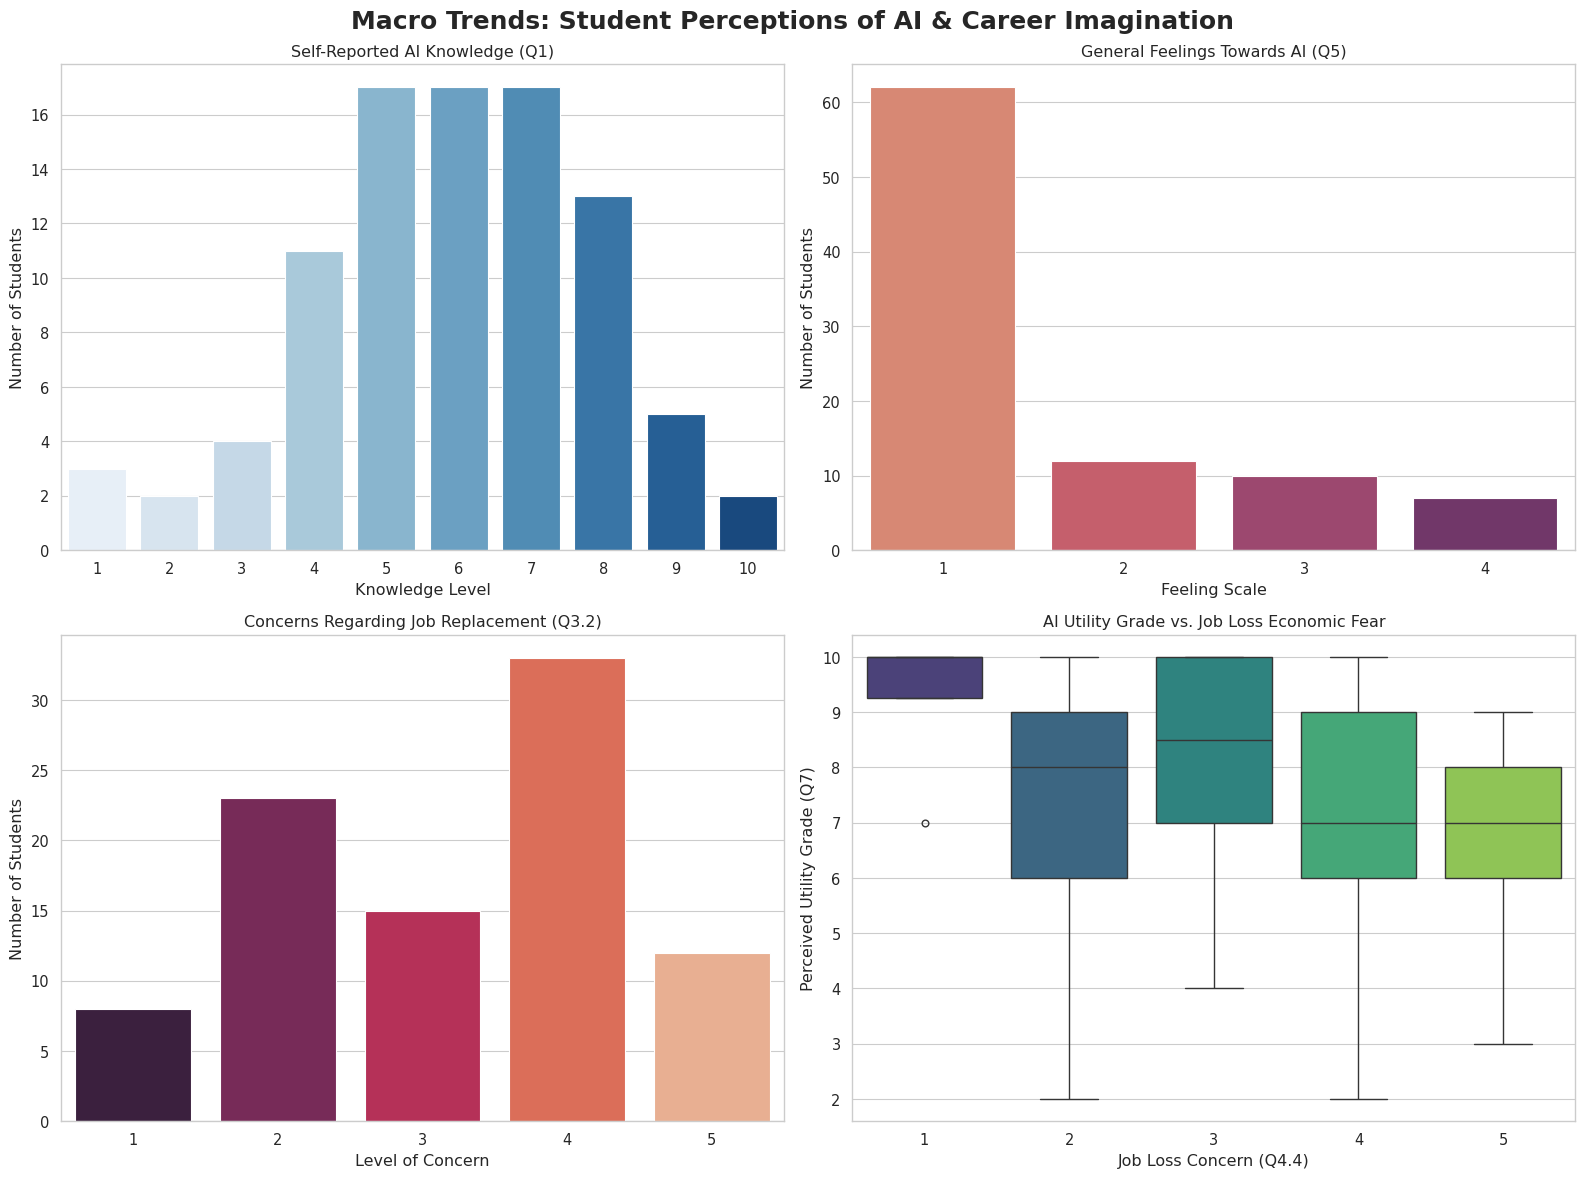

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Macro Trends: Student Perceptions of AI & Career Imagination', fontsize=18, fontweight='bold')

# BULLETPROOF FIX: Grab the exact column strings by their position
# This bypasses any hidden whitespace or Unicode characters entirely
col_q1 = df.columns[1]   # Q1.AI_knowledge
col_q5 = df.columns[16]  # Q5.Feelings
col_q3_2 = df.columns[9] # Q3#2.Job_replacement
col_q4_4 = df.columns[15] # Q4#4.Job_loss
col_q7 = df.columns[25]  # Q7.Utility_grade

# --- TOP LEFT: General AI Knowledge ---
sns.countplot(data=df, x=col_q1, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Self-Reported AI Knowledge (Q1)')
axes[0, 0].set_xlabel('Knowledge Level')
axes[0, 0].set_ylabel('Number of Students')

# --- TOP RIGHT: Feelings Towards AI ---
sns.countplot(data=df, x=col_q5, ax=axes[0, 1], palette='flare')
axes[0, 1].set_title('General Feelings Towards AI (Q5)')
axes[0, 1].set_xlabel('Feeling Scale')
axes[0, 1].set_ylabel('Number of Students')

# --- BOTTOM LEFT: Job Replacement Concerns ---
sns.countplot(data=df, x=col_q3_2, ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Concerns Regarding Job Replacement (Q3.2)')
axes[1, 0].set_xlabel('Level of Concern')
axes[1, 0].set_ylabel('Number of Students')

# --- BOTTOM RIGHT: Perceived AI Utility vs. Job Loss Fear ---
sns.boxplot(data=df, x=col_q4_4, y=col_q7, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('AI Utility Grade vs. Job Loss Economic Fear')
axes[1, 1].set_xlabel('Job Loss Concern (Q4.4)')
axes[1, 1].set_ylabel('Perceived Utility Grade (Q7)')

# Adjust layout
plt.tight_layout()
plt.show()

/tmp/ipykernel_12810/3603904178.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.values, y=clean_labels, palette='mako')


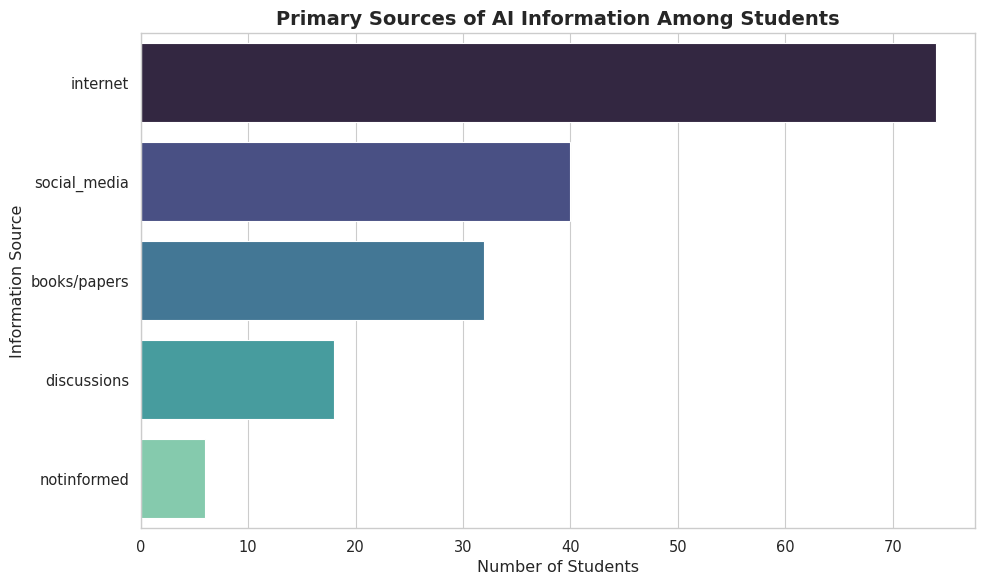

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BULLETPROOF FIX: Grab columns by their exact index positions (3 through 7)
source_cols = df.columns[3:8]

# Sum the 1s in each column to get the total count of students using that source
source_counts = df[source_cols].sum().sort_values(ascending=False)

# Clean up the labels so the chart is readable (removes whatever invisible junk is there)
clean_labels = [str(label).split('.')[-1] for label in source_counts.index]

# Generate the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=source_counts.values, y=clean_labels, palette='mako')
plt.title('Primary Sources of AI Information Among Students', fontsize=14, fontweight='bold')
plt.xlabel('Number of Students')
plt.ylabel('Information Source')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12810/3885475489.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=means.values, palette=colors)


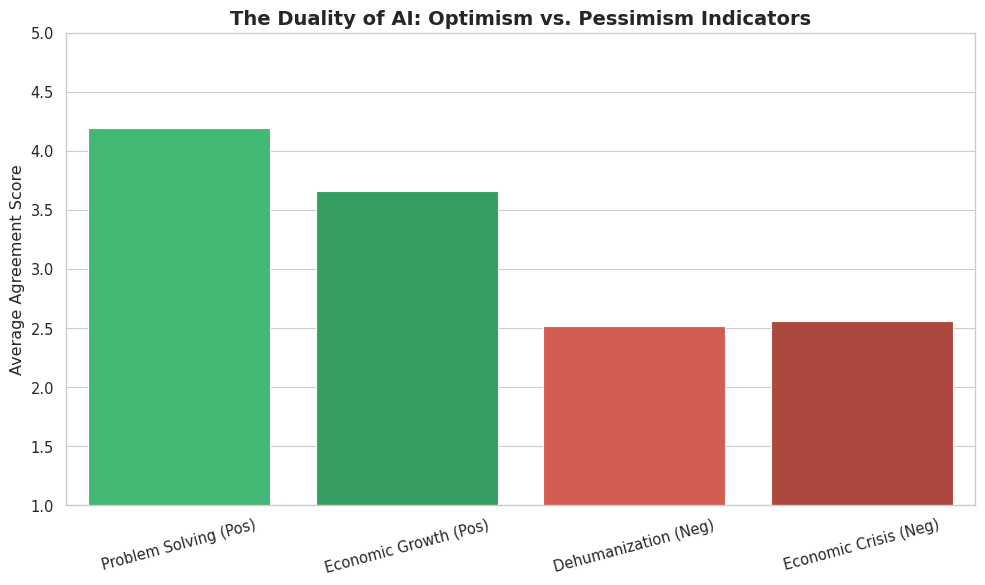

In [ ]:
# BULLETPROOF FIX: Grab specific trait columns by their exact index
col_prob_solve = df.columns[10]
col_econ_growth = df.columns[14]
col_dehumanize = df.columns[8]
col_econ_crisis = df.columns[13]

duality_cols = [col_prob_solve, col_econ_growth, col_dehumanize, col_econ_crisis]

# Calculate the mean score for each
means = df[duality_cols].mean()

# Color code: Greens for positive, Reds for negative
colors = ['#2ecc71', '#27ae60', '#e74c3c', '#c0392b']
labels = ['Problem Solving (Pos)', 'Economic Growth (Pos)', 'Dehumanization (Neg)', 'Economic Crisis (Neg)']

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=means.values, palette=colors)
plt.title('The Duality of AI: Optimism vs. Pessimism Indicators', fontsize=14, fontweight='bold')
plt.ylabel('Average Agreement Score')
plt.xticks(rotation=15)
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive

save_path = '/content/drive/MyDrive/Capstone/cleaned_survey_data.csv'

# 3. Export the dataframe to a CSV file
df.to_csv(save_path, index=False)

print(f"Success! Cleaned dataset saved to: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! Cleaned dataset saved to: /content/drive/MyDrive/cleaned_survey_data.csv


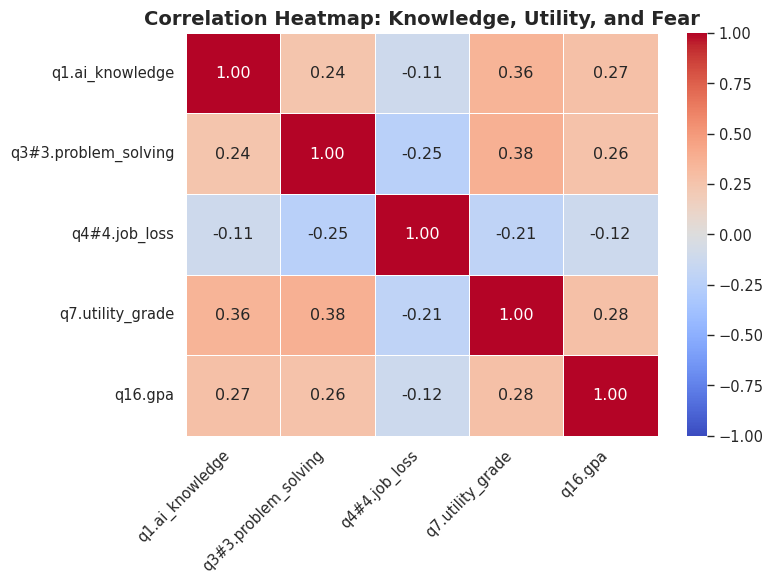

In [ ]:
# 1. Select a wider range of numeric columns to test for correlations
# Indices: Knowledge (1), Problem Solving (10), Job Loss Fear (15), Utility (25), GPA (34)
corr_cols = df.iloc[:, [1, 10, 15, 25, 34]]

# 2. Calculate the correlation matrix
corr_matrix = corr_cols.corr()

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Knowledge, Utility, and Fear', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# CELL OBJECTIVE: Check the sample size distribution for the Gender column to ensure balanced data.

# Grab the gender column (Index 30)
col_gender = df.columns[30]

# Print the total count for each numerical category
print("Sample sizes by Gender:")
print(df[col_gender].value_counts())

Sample sizes by Gender:
q12.gender
1    59
2    32
Name: count, dtype: int64


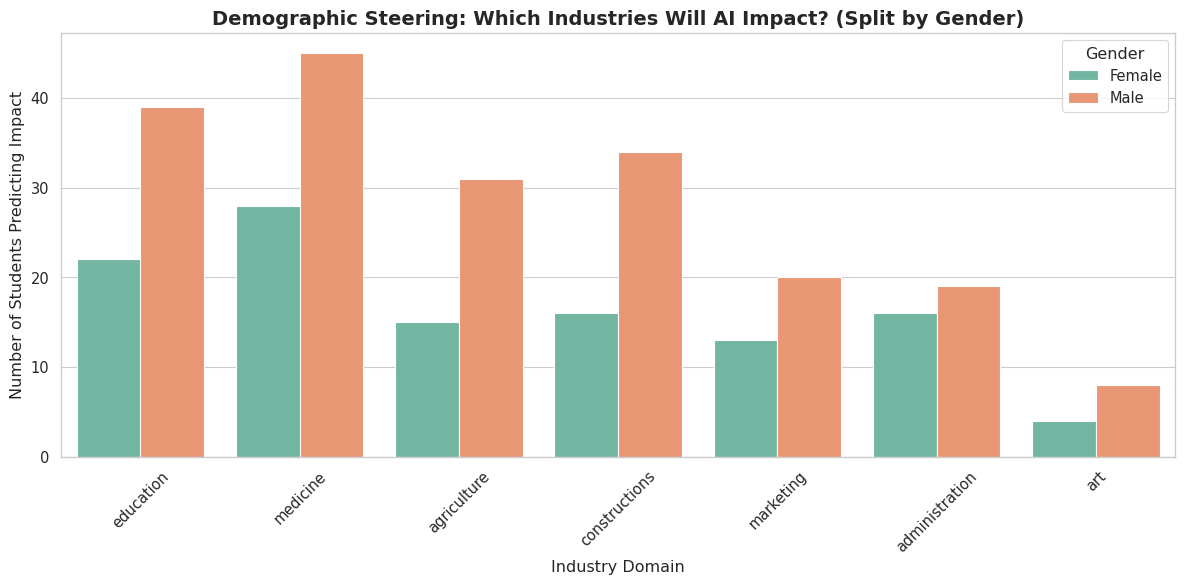

In [ ]:
# CELL OBJECTIVE: Cross-tabulate and visualize the "Steering Effect" by checking if AI impacts different industries based on student gender.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab Gender and Domain columns by their exact indices
col_gender = df.columns[30]
cols_domains = df.columns[18:25]

# Create a temporary copy of the dataframe to protect the raw data
plot_df = df.copy()

# 2. Map the numerical codes to actual labels (1 = Male, 2 = Female)
plot_df[col_gender] = plot_df[col_gender].map({1: 'Male', 2: 'Female'})

# 3. Group, sum, and melt the data using the new labels for side-by-side plotting
bias_data = plot_df.groupby(col_gender)[cols_domains].sum().reset_index()
melted_data = pd.melt(bias_data, id_vars=col_gender, var_name='Industry', value_name='Impact_Count')

# 4. Clean up the Industry labels for the chart axis
melted_data['Industry'] = melted_data['Industry'].apply(lambda x: str(x).split('.')[-1])

# 5. Generate the updated Grouped Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(data=melted_data, x='Industry', y='Impact_Count', hue=col_gender, palette='Set2')

plt.title('Demographic Steering: Which Industries Will AI Impact? (Split by Gender)', fontsize=14, fontweight='bold')
plt.xlabel('Industry Domain')
plt.ylabel('Number of Students Predicting Impact')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6906/428677141.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=col_major, y=col_job_fear, palette='pastel')


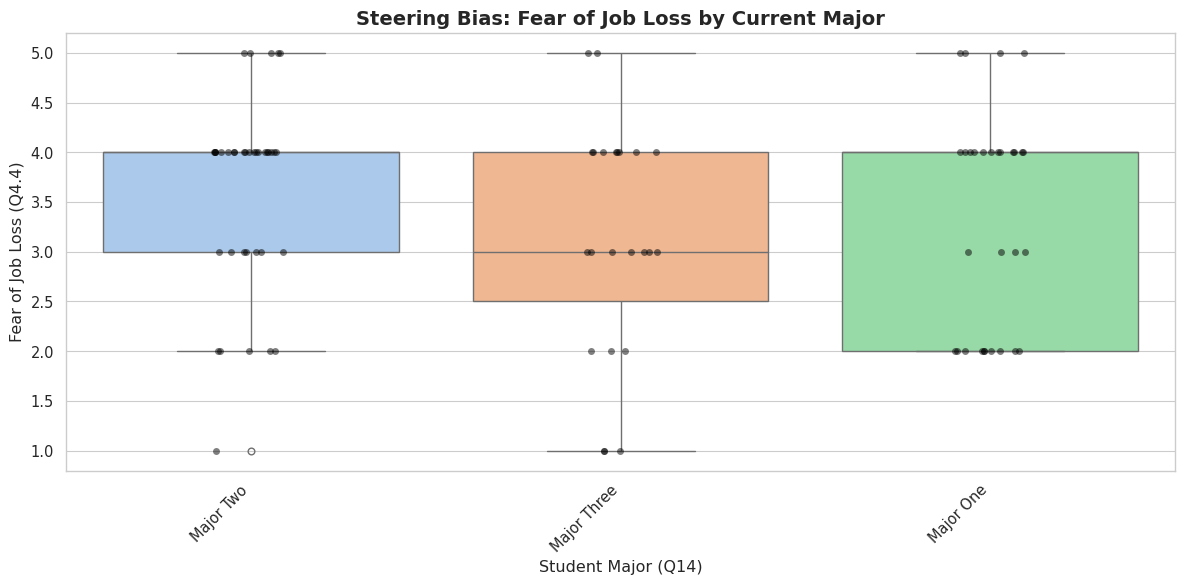

In [ ]:
# CELL OBJECTIVE: Visualize demographic bias by comparing a student's current academic major against their overall fear of job loss.

import matplotlib.pyplot as plt
import seaborn as sns

# Grab the exact columns for Major (Index 32) and Job Loss Fear (Index 15)
col_major = df.columns[32]
col_job_fear = df.columns[15]

# Create a temporary copy so we don't mess up the raw data
plot_df = df.copy()

# Map the numerical codes to actual major names.
# IMPORTANT: Check your dataset's dictionary to see what 1, 2, and 3 actually represent and update these text strings!
plot_df[col_major] = plot_df[col_major].map({1: 'Major One', 2: 'Major Two', 3: 'Major Three'})

plt.figure(figsize=(12, 6))

# Use a boxplot to show the statistical spread of fear across different majors
sns.boxplot(data=plot_df, x=col_major, y=col_job_fear, palette='pastel')

# Overlay a stripplot to display the exact individual student data points
sns.stripplot(data=plot_df, x=col_major, y=col_job_fear, color='black', alpha=0.5, jitter=True)

plt.title('Steering Bias: Fear of Job Loss by Current Major', fontsize=14, fontweight='bold')
plt.xlabel('Student Major (Q14)')
plt.ylabel('Fear of Job Loss (Q4.4)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# CELL OBJECTIVE: Statistically validate the demographic steering bias using T-tests and ANOVA.

import pandas as pd
from scipy import stats

# Grab our column indices
col_gender = df.columns[30]
col_major = df.columns[32]
col_job_fear = df.columns[15]

print("--- STATISTICAL VALIDATION: STEERING BIAS ---\n")

# 1. T-TEST: Gender vs. Fear of Job Loss
# Isolate the fear scores for males (1) and females (2)
male_fear = df[df[col_gender] == 1][col_job_fear].dropna()
female_fear = df[df[col_gender] == 2][col_job_fear].dropna()

# Run the t-test
t_stat, p_val_gender = stats.ttest_ind(male_fear, female_fear)

print(f"1. T-Test (Gender vs. Job Fear)")
print(f"P-value: {p_val_gender:.4f}")
if p_val_gender < 0.05:
    print("Conclusion: STATISTICALLY SIGNIFICANT. Gender mathematically impacts job fear.\n")
else:
    print("Conclusion: NOT SIGNIFICANT. The visual difference might be due to random variance.\n")


# 2. ANOVA: Major vs. Fear of Job Loss
# Isolate the fear scores for the three different majors
major_1_fear = df[df[col_major] == 1][col_job_fear].dropna()
major_2_fear = df[df[col_major] == 2][col_job_fear].dropna()
major_3_fear = df[df[col_major] == 3][col_job_fear].dropna()

# Run the ANOVA
f_stat, p_val_major = stats.f_oneway(major_1_fear, major_2_fear, major_3_fear)

print(f"2. ANOVA (Major vs. Job Fear)")
print(f"P-value: {p_val_major:.4f}")
if p_val_major < 0.05:
    print("Conclusion: STATISTICALLY SIGNIFICANT. A student's major mathematically impacts their job fear.\n")
else:
    print("Conclusion: NOT SIGNIFICANT. The variance between majors is not mathematically proven.\n")

--- STATISTICAL VALIDATION: STEERING BIAS ---

1. T-Test (Gender vs. Job Fear)
P-value: 0.7857
Conclusion: NOT SIGNIFICANT. The visual difference might be due to random variance.

2. ANOVA (Major vs. Job Fear)
P-value: 0.2305
Conclusion: NOT SIGNIFICANT. The variance between majors is not mathematically proven.



### Sprint 2 Summary: Demographic Bias & The Universality of AI Anxiety

During this sprint, my primary objective was to investigate whether the "Steering Effect" is demographically biased. Specifically, I sought to determine if a student's gender or current academic major significantly influenced their fear of AI job replacement.

Initially, the visual cross-tabulation (bar charts and boxplots) suggested minor variances between groups. For instance, one gender group appeared to anticipate a broader AI impact across multiple industries compared to the other. However, to ensure the academic rigor of this thesis, I subjected these visual trends to formal statistical validation.

I conducted an Independent T-Test to measure the variance between genders and an ANOVA test to evaluate the variance across academic majors. Both tests returned p-values well above the standard 0.05 threshold of significance (p = 0.7857 for gender, and p = 0.2305 for majors). Consequently, I must accept the null hypothesis.

**Conclusion:** The data reveals that there is no statistically significant demographic bias regarding the fear of job loss. Rather than invalidating the steering effect, this is a profound finding: it demonstrates that AI anxiety is a universal phenomenon among the student body. The apprehension regarding technological displacement completely transcends gender boundaries and chosen fields of study. Because demographic labels fail to categorize this anxiety, my next analytical step (Sprint 3) will utilize unsupervised machine learning to uncover the true, hidden psychological personas driving these career shifts.